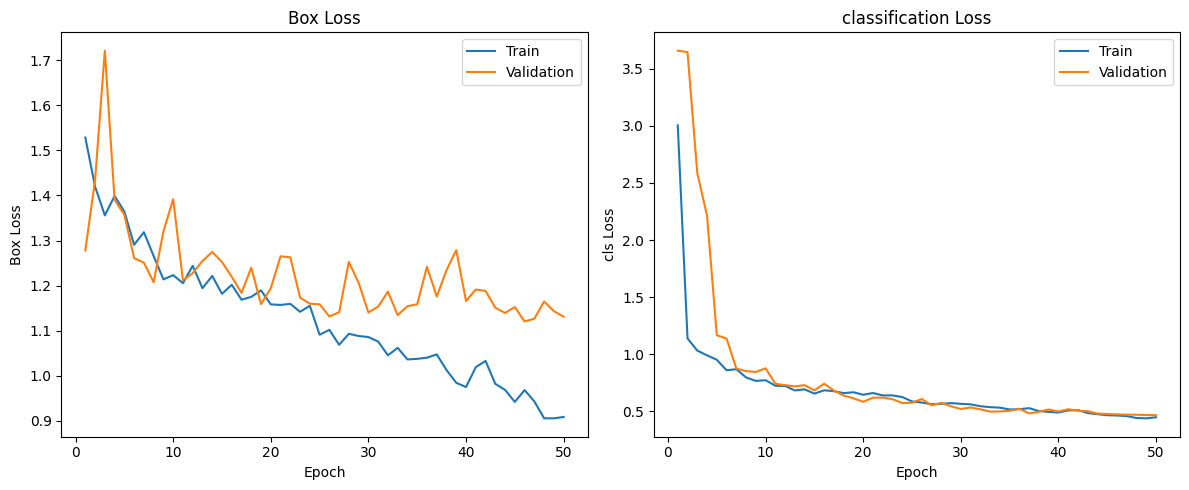

In [ ]:
plt.figure(figsize=(12,5))
# Box Loss
plt.subplot(1,2,1)
plt.plot(df['epoch'],df['train/box_loss'])
plt.plot(df['epoch'],df['val/box_loss'])
plt.xlabel('Epoch')
plt.ylabel('Box Loss')
plt.title('Box Loss')
plt.legend(['Train','Validation'])

# Class Loss
plt.subplot(1,2,2)
plt.plot(df['epoch'],df['train/cls_loss'])
plt.plot(df['epoch'],df['val/cls_loss'])
plt.xlabel('Epoch')
plt.ylabel('cls Loss')
plt.title('classification Loss')
plt.legend(['Train','Validation'])

plt.tight_layout()
plt.show()

In [ ]:
print(f"Peak Validation mAP@0.5:{(df['metrics/mAP50(B)'].max())}")
print(f"Final Validation mAP@0.5:{(df.iloc[-1]['metrics/mAP50(B)'])}")

Peak Validation mAP@0.5:0.99454
Final Validation mAP@0.5:0.99379


In [ ]:
import shutil,os

In [ ]:
shutil.copytree('/content/drive/MyDrive/Car_detection_problem/dataset', '/content/dataset')

'/content/dataset'

In [ ]:
import yaml
with open ('/content/data.yaml','w') as f:
    yaml.dump({'path':os.path.abspath('/content/dataset'),'train':'images/train','val':'images/val','nc':1,'names':['car']},
             f,default_flow_style=False,sort_keys=False)

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 8.4 MB/s eta 0:00:00


In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.4/107.7 GB disk)


In [ ]:
from ultralytics import YOLO

In [ ]:
drive_save_dir='/content/drive/MyDrive/Car_detection_problem'

In [ ]:
model=YOLO('yolov8n.pt')

In [ ]:
results=model.train(data='/content/data.yaml',epochs=50,
                    imgsz=640,batch=16,project=drive_save_dir,name='Result_of_training2',patience=10,
                    weight_decay=0.001,box=7.5,mosaic=1.0,close_mosaic=10,scale=0.5,translate=0.2,fliplr=0.5,seed=42)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Result_of_training2-2, nbs=64, nms=None, opset=None, optim

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Car_detection_problem/Result_of_training2-2/results.csv')
df.columns=df.columns.str.strip()

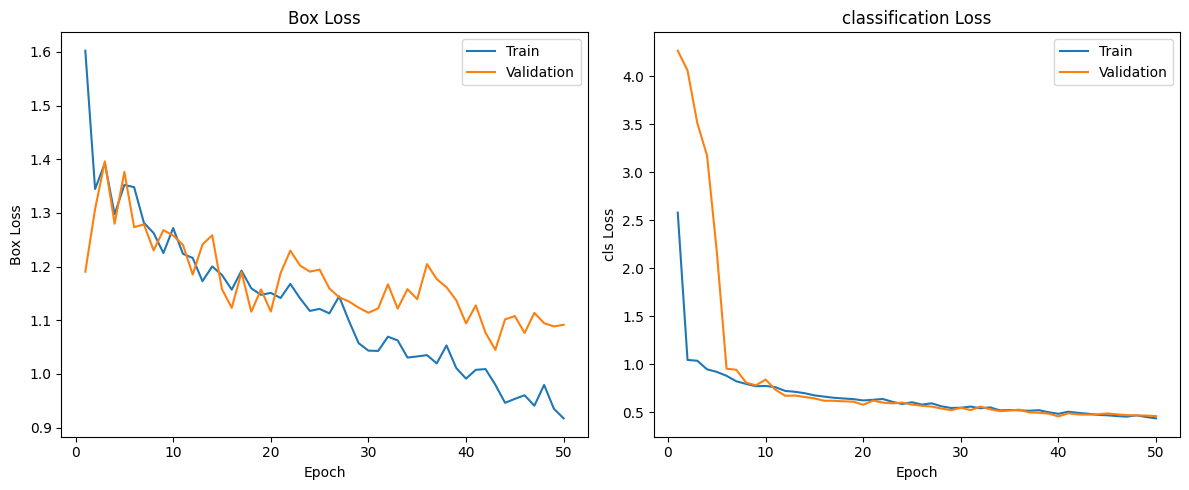

In [ ]:
plt.figure(figsize=(12,5))
# Box Loss
plt.subplot(1,2,1)
plt.plot(df['epoch'],df['train/box_loss'])
plt.plot(df['epoch'],df['val/box_loss'])
plt.xlabel('Epoch')
plt.ylabel('Box Loss')
plt.title('Box Loss')
plt.legend(['Train','Validation'])

# Class Loss
plt.subplot(1,2,2)
plt.plot(df['epoch'],df['train/cls_loss'])
plt.plot(df['epoch'],df['val/cls_loss'])
plt.xlabel('Epoch')
plt.ylabel('cls Loss')
plt.title('classification Loss')
plt.legend(['Train','Validation'])

plt.tight_layout()
plt.show()

# Testing of model on testing imges

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 6.3 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [4]:
model = YOLO('/content/drive/MyDrive/Car_detection_problem/Result_of_training2-2/weights/best.pt')

In [5]:
test_results = model.predict(
    source='/content/drive/MyDrive/Car_detection_problem/testing_images',
    conf=0.25,
    save=Fals,
    verbose=True
)


image 1/175 /content/drive/MyDrive/Car_detection_problem/testing_images/vid_5_25100.jpg: 384x640 (no detections), 229.0ms
image 2/175 /content/drive/MyDrive/Car_detection_problem/testing_images/vid_5_25120.jpg: 384x640 (no detections), 88.6ms
image 3/175 /content/drive/MyDrive/Car_detection_problem/testing_images/vid_5_25140.jpg: 384x640 (no detections), 71.3ms
image 4/175 /content/drive/MyDrive/Car_detection_problem/testing_images/vid_5_25160.jpg: 384x640 (no detections), 71.9ms
image 5/175 /content/drive/MyDrive/Car_detection_problem/testing_images/vid_5_25180.jpg: 384x640 (no detections), 69.6ms
image 6/175 /content/drive/MyDrive/Car_detection_problem/testing_images/vid_5_25200.jpg: 384x640 (no detections), 74.4ms
image 7/175 /content/drive/MyDrive/Car_detection_problem/testing_images/vid_5_25220.jpg: 384x640 (no detections), 73.7ms
image 8/175 /content/drive/MyDrive/Car_detection_problem/testing_images/vid_5_25240.jpg: 384x640 (no detections), 69.6ms
image 9/175 /content/drive/MyD

In [ ]:
for result in test_results:
  plt.figure(figsize=(12,5))
  annotated_frame_bgr = result.plot()
  annotated_frame_rgb = annotated_frame_bgr[..., ::-1]
  image_name = os.path.basename(result.path)
  box_count = len(result.boxes)
  plt.imshow(annotated_frame_rgb)
  plt.title(f"{image_name}\n({box_count} cars detected)")
  plt.axis("off")
  plt.tight_layout()
  plt.show()

Output hidden; open in https://colab.research.google.com to view.